# １章３節２項 衛星の軌道

## 概要
SAR衛星の軌道情報の読み込みとその結果の地球楕円体との可視化です。

## 使用データ

| 項目 | 情報 |
| ---- | ---- | 
| 衛星 | ALOS PALSAR |
| 観測シーンID　| `Frame 424`, `Path 620` のシーン |
| データリンク | [Github](../data/sakurazima/) ,[ASF](https://search.asf.alaska.edu/#/?zoom=9.323&center=130.581,31.153&polygon=POLYGON((130.6321%2031.5659,130.6923%2031.5659,130.6923%2031.6076,130.6321%2031.6076,130.6321%2031.5659))&dataset=ALOS&resultsLoaded=true&granule=ALPSRP277080620-L1.1&searchType=Geographic%20Search&searchList=ALPSRP102620620&productTypes=L1.1&beamModes=FBS&polarizations=HH&flightDirs=Ascending&path=424-&frame=620-) Level 1.1 Image |
| 画像クレジット| © JAXA |


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

PATH_OUTPUT = 'output/1_3_2/'
os.makedirs(PATH_OUTPUT, exist_ok=True)

In [2]:
PATH_ROOT = '../'

IMGS = [
    
    # ずれてる
    {
        "led": f'{PATH_ROOT}data/sakurazima/ALPSRP243530620-H1.1__A/LED-ALPSRP243530620-H1.1__A',
        'img': f'{PATH_ROOT}data/sakurazima/ALPSRP243530620-H1.1__A/IMG-HH-ALPSRP243530620-H1.1__A',
    },
    # 1
    {
        "led": f'{PATH_ROOT}data/sakurazima/ALPSRP209980620-H1.1__A/LED-ALPSRP209980620-H1.1__A',
        'img': f'{PATH_ROOT}data/sakurazima/ALPSRP209980620-H1.1__A/IMG-HH-ALPSRP209980620-H1.1__A',
    },
    # 2
    {
        'led': f'{PATH_ROOT}data/sakurazima/ALPSRP223400620-H1.1__A/LED-ALPSRP223400620-H1.1__A',
        'img': f'{PATH_ROOT}data/sakurazima/ALPSRP223400620-H1.1__A/IMG-HH-ALPSRP223400620-H1.1__A',
    },
    # 3
    {
        'led': f'{PATH_ROOT}data/sakurazima/ALPSRP216690620-H1.1__A/LED-ALPSRP216690620-H1.1__A',
        'img': f'{PATH_ROOT}data/sakurazima/ALPSRP216690620-H1.1__A/IMG-HH-ALPSRP216690620-H1.1__A',
    },
    
    # # 4
    {
        'led': f'{PATH_ROOT}data/sakurazima/ALPSRP209980620-H1.1__A/LED-ALPSRP209980620-H1.1__A',
        'img': f'{PATH_ROOT}data/sakurazima/ALPSRP209980620-H1.1__A/IMG-HH-ALPSRP209980620-H1.1__A',
    },
    # # 5
    {
        'led': f'{PATH_ROOT}data/sakurazima/ALPSRP163010620-H1.1__A/LED-ALPSRP163010620-H1.1__A',
        'img': f'{PATH_ROOT}data/sakurazima/ALPSRP163010620-H1.1__A/IMG-HH-ALPSRP163010620-H1.1__A',
    },
    # # 6
    {
        'led': f'{PATH_ROOT}data/sakurazima/ALPSRP156300620-H1.1__A/LED-ALPSRP156300620-H1.1__A',
        'img': f'{PATH_ROOT}data/sakurazima/ALPSRP156300620-H1.1__A/IMG-HH-ALPSRP156300620-H1.1__A',
    },
    # # 7
    {
        'led': f'{PATH_ROOT}data/sakurazima/ALPSRP116040620-H1.1__A/LED-ALPSRP116040620-H1.1__A',
        'img': f'{PATH_ROOT}data/sakurazima/ALPSRP116040620-H1.1__A/IMG-HH-ALPSRP116040620-H1.1__A',
    },
    # # 8
    {
        'led': f'{PATH_ROOT}data/sakurazima/ALPSRP109330620-H1.1__A/LED-ALPSRP109330620-H1.1__A',
        'img': f'{PATH_ROOT}data/sakurazima/ALPSRP109330620-H1.1__A/IMG-HH-ALPSRP109330620-H1.1__A',
    },
    # # 9
    {
        'led': f'{PATH_ROOT}data/sakurazima/ALPSRP102620620-H1.1__A/LED-ALPSRP102620620-H1.1__A',
        'img': f'{PATH_ROOT}data/sakurazima/ALPSRP102620620-H1.1__A/IMG-HH-ALPSRP102620620-H1.1__A',
    },
    # # 10
    {
        'led': f'{PATH_ROOT}data/sakurazima/ALPSRP095910620-H1.1__A/LED-ALPSRP095910620-H1.1__A',
        'img': f'{PATH_ROOT}data/sakurazima/ALPSRP095910620-H1.1__A/IMG-HH-ALPSRP095910620-H1.1__A',
    },

]

len(IMGS)

11

In [3]:
def get_sat_pos(PATH_LED, PATH_IMG):
    with open(PATH_LED, 'rb') as led:
        led.seek(720+4096+0+140)
        position_num = int(led.read(4))

        pos_ary = [];
        
        # プラットフォーム位置データレコードのデータポイント位置ベクトル(x,y,z/m)を、データポイント数分取得する。
        # データポイントとは、衛星が1枚の画像を撮影している間(約10秒間)の、衛星の観測点である。
        # その10秒間で衛星は100km程度移動するため、適切に補完を行い、画像の各ピクセルが取得されたときの衛星の位置を特定する。
        led.seek(720+4096+0+386)
        for i in range(position_num):
            for j in range(3):
                pos = float(led.read(22))
                pos_ary.append(pos)
            led.read(66)
    pos_ary = np.array(pos_ary).reshape(-1,3)
    return pos_ary

POS_S = [get_sat_pos(_IMG['led'], _IMG['img']) for _IMG in IMGS]
len(POS_S)

11

In [4]:
POS_S[0].shape

(28, 3)

In [5]:
NAMES = [_IMG['led'].split('/')[-1].split('-')[1] for _IMG in IMGS]
NAMES

['ALPSRP243530620',
 'ALPSRP209980620',
 'ALPSRP223400620',
 'ALPSRP216690620',
 'ALPSRP209980620',
 'ALPSRP163010620',
 'ALPSRP156300620',
 'ALPSRP116040620',
 'ALPSRP109330620',
 'ALPSRP102620620',
 'ALPSRP095910620']

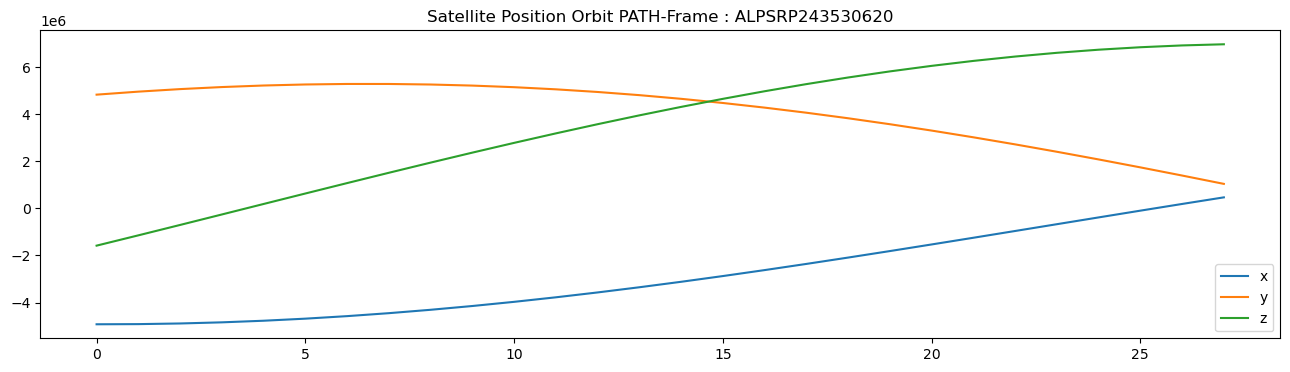

In [6]:
plt.figure(figsize=(16,4), facecolor='white',edgecolor='black')
plt.title(f'Satellite Position Orbit PATH-Frame : {NAMES[0]}')
plt.plot(POS_S[0][:,0], label='x')
plt.plot(POS_S[0][:,1], label='y')
plt.plot(POS_S[0][:,2], label='z')
plt.legend()
plt.savefig(f'{PATH_OUTPUT}pos_0.png')
plt.show();
plt.clf()
plt.close()

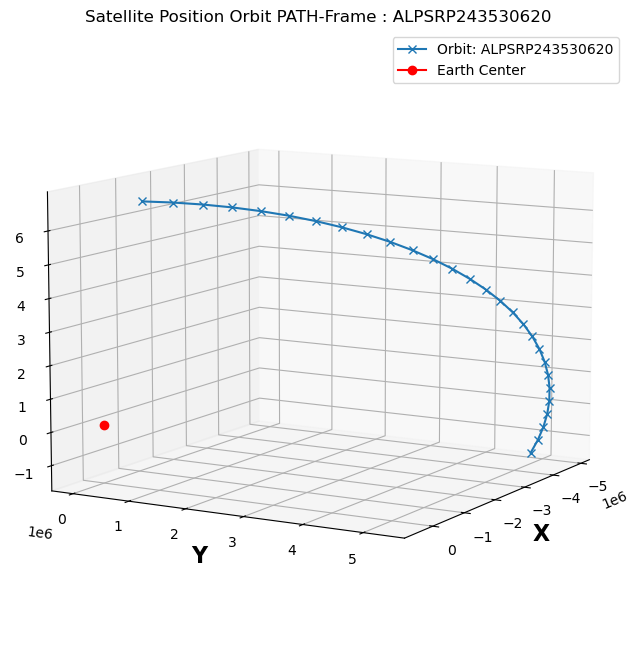

In [7]:
## 3D plot XYZ coordinates
fig = plt.figure(figsize=(20,8), facecolor='white',edgecolor='black')
ax = fig.add_subplot(111, projection='3d')

ax.set_zlabel('Z', fontdict={'size': 16}, fontweight='bold')
ax.set_xlabel('X', fontdict={'size': 16}, fontweight='bold')
ax.set_ylabel('Y', fontdict={'size': 16}, fontweight='bold')

ax.plot(POS_S[0][:,0], POS_S[0][:,1], POS_S[0][:,2], marker="x" , label=f'Orbit: {NAMES[0]}')
ax.plot(0, 0, 0, marker="o", color='red', label='Earth Center')

plt.title(f'Satellite Position Orbit PATH-Frame : {NAMES[0]}')
plt.legend()
# 格子点の表示
ax.grid(True)
# 視点の変更
ax.view_init(elev=10, azim=30)
plt.savefig(f'{PATH_OUTPUT}pos_3d_0.png')
plt.show();
plt.clf()
plt.close()

## Orbit Prepare

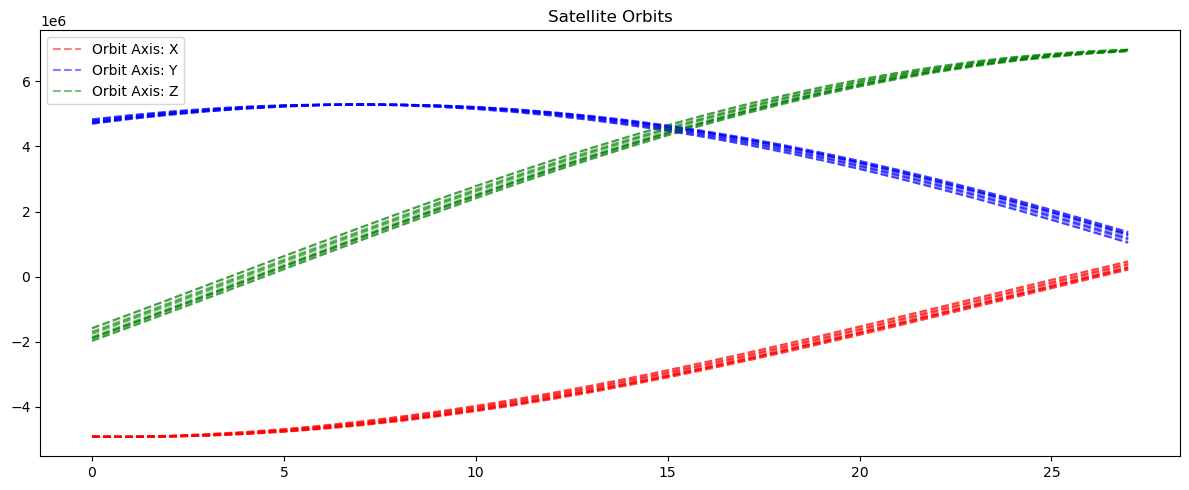

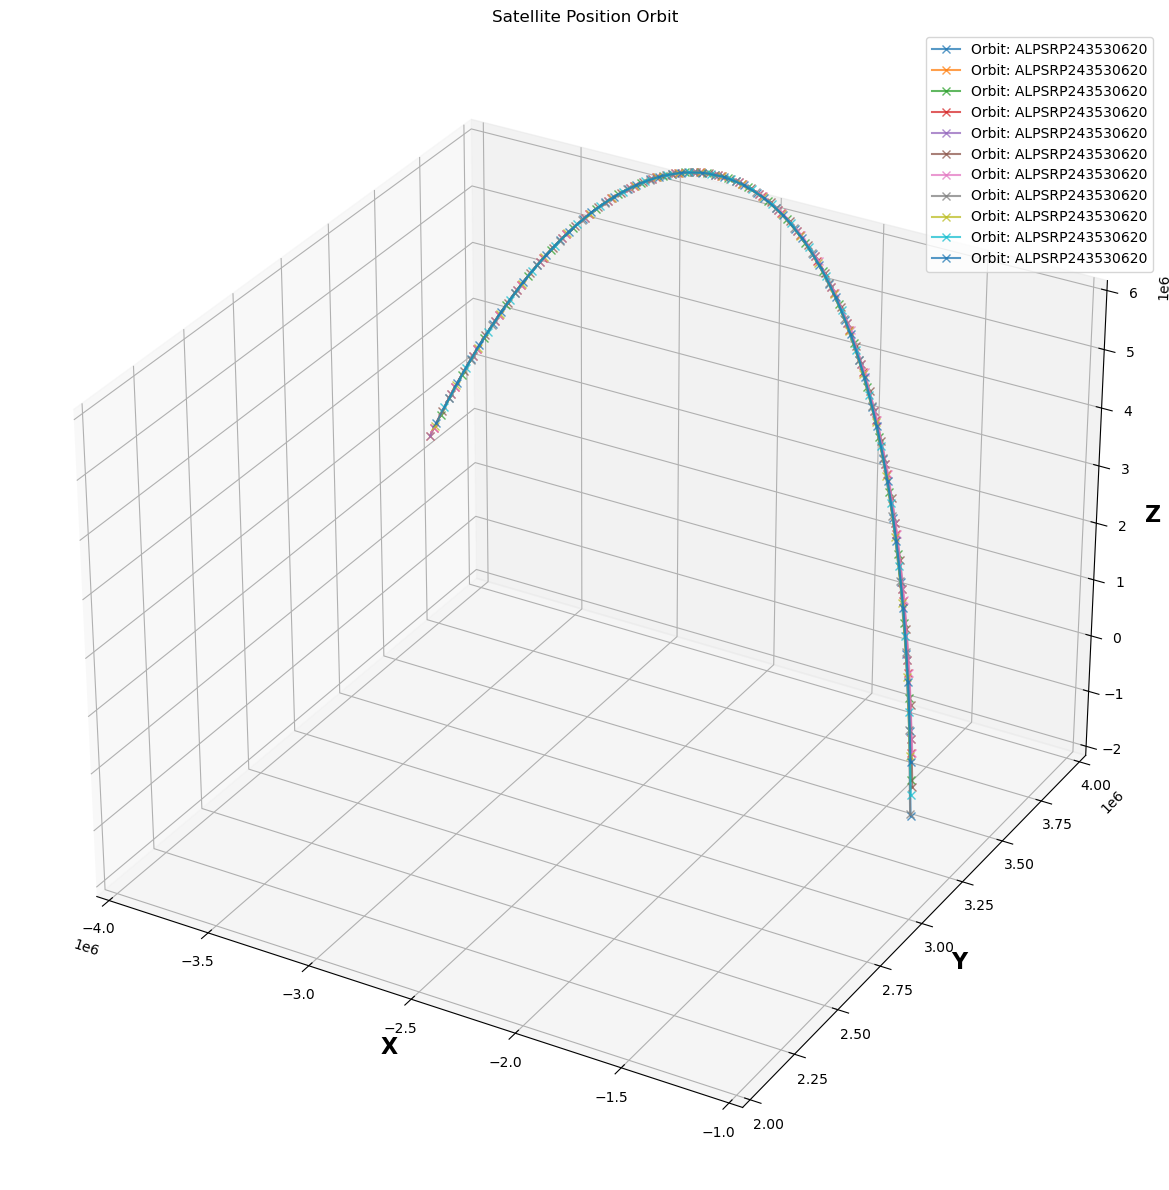

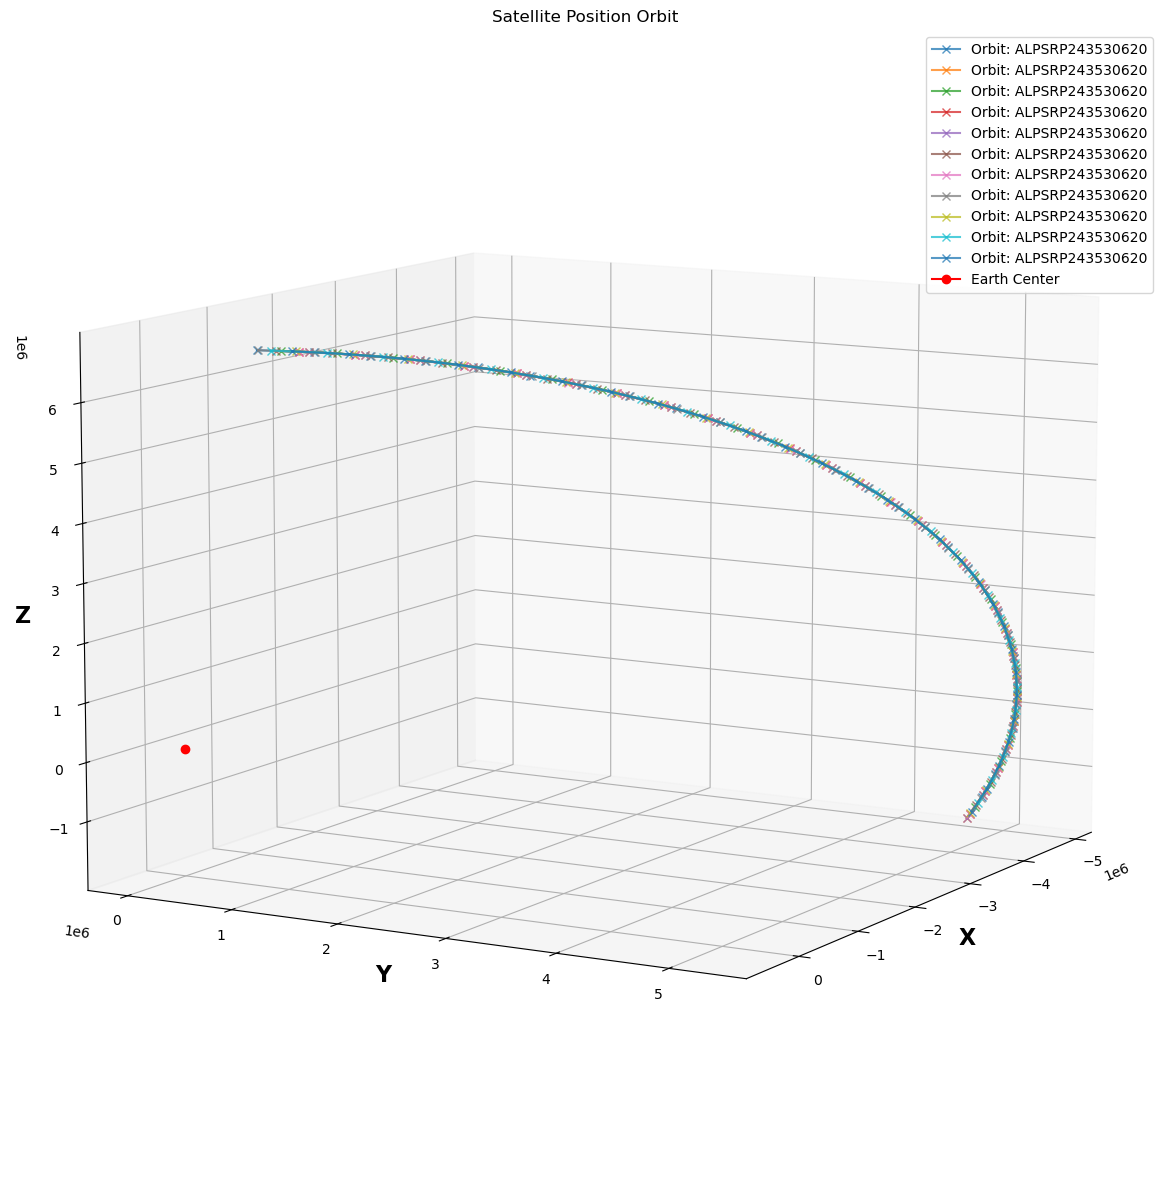

In [ ]:

    
plt.figure(figsize=(12,5), facecolor='white',edgecolor='black')
plt.title(f'Satellite Orbits')
for _i, _POS in enumerate(IMGS):
    plt.plot(POS_S[_i][:,0], color='red', alpha=0.5, linestyle='dashed')
    plt.plot(POS_S[_i][:,1], color='blue', alpha=0.5, linestyle='dashed')
    plt.plot(POS_S[_i][:,2], color='green', alpha=0.5, linestyle='dashed')
plt.legend(['Orbit Axis: X', 'Orbit Axis: Y', 'Orbit Axis: Z'])
plt.tight_layout()
plt.savefig(f'{PATH_OUTPUT}pos_2d.png')
plt.show();plt.clf();plt.close()

xmin, xmax = 1E6 * -4, 1E6 * -1
ymin, ymax = 1E6 * 2, 1E6 * 4
zmin, zmax = 1E6 * -2, 1E6 * 6

fig = plt.figure(figsize=(24,12), facecolor='white',edgecolor='black')
ax = fig.add_subplot(111, projection='3d')

ax.set_zlabel('Z', fontdict={'size': 16}, fontweight='bold')
ax.set_xlabel('X', fontdict={'size': 16}, fontweight='bold')
ax.set_ylabel('Y', fontdict={'size': 16}, fontweight='bold')

ax.set_xlim3d(xmin, xmax)
ax.set_ylim3d(ymin, ymax)
ax.set_zlim3d(zmin, zmax)
for _i, _POS in enumerate(IMGS):
    ax.plot(POS_S[_i][:,0], POS_S[_i][:,1], POS_S[_i][:,2], marker="x" , label=f'Orbit: {NAMES[0]}', alpha=0.75,)
plt.title(f'Satellite Position Orbit')
plt.legend()
# 格子点の表示
ax.grid(True)
plt.tight_layout()
plt.savefig(f'{PATH_OUTPUT}pos_3d_with_earth.png')
plt.show();
plt.clf()
plt.close()

fig = plt.figure(figsize=(24,12), facecolor='white',edgecolor='black')
ax = fig.add_subplot(111, projection='3d')

ax.set_zlabel('Z', fontdict={'size': 16}, fontweight='bold')
ax.set_xlabel('X', fontdict={'size': 16}, fontweight='bold')
ax.set_ylabel('Y', fontdict={'size': 16}, fontweight='bold')
for _i, _POS in enumerate(IMGS):
    ax.plot(POS_S[_i][:,0], POS_S[_i][:,1], POS_S[_i][:,2], marker="x" , label=f'Orbit: {NAMES[0]}', alpha=0.75,)
ax.plot(0, 0, 0, marker="o", color='red', label='Earth Center')

plt.title(f'Satellite Position Orbit')
plt.legend()
# 格子点の表示
ax.grid(True)
# 視点の変更
ax.view_init(elev=10, azim=30)
plt.tight_layout()
plt.savefig(f'{PATH_OUTPUT}pos_3d_with_earth.png')
plt.show();plt.clf();plt.close()

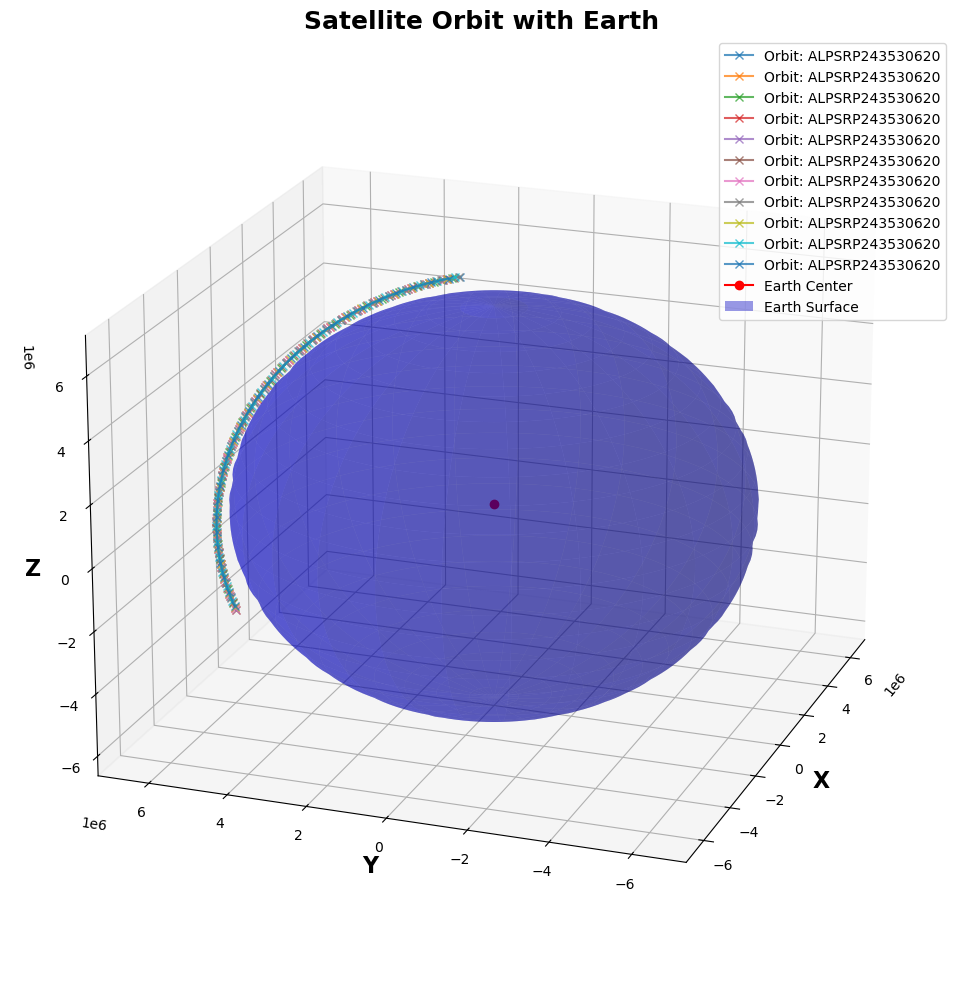

In [24]:
EARTH_RADIUS_LONG = 6378136.62
EARTH_RADIUS_SHORT = 6356752.3142

u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
u, v = np.meshgrid(u, v)
x = EARTH_RADIUS_LONG * np.cos(u) * np.sin(v)
y = EARTH_RADIUS_LONG * np.sin(u) * np.sin(v)
z = EARTH_RADIUS_SHORT * np.cos(v)

fig = plt.figure(figsize=(12 ,10), facecolor='white',edgecolor='black')
ax = fig.add_subplot(111, projection='3d')
ax.set_zlabel('Z', fontdict={'size': 16}, fontweight='bold')
ax.set_xlabel('X', fontdict={'size': 16}, fontweight='bold')
ax.set_ylabel('Y', fontdict={'size': 16}, fontweight='bold')
for _i, _POS in enumerate(IMGS):
    ax.plot(POS_S[_i][:,0], POS_S[_i][:,1], POS_S[_i][:,2], marker="x" , label=f'Orbit: {NAMES[0]}', alpha=0.75,)
ax.plot(0, 0, 0, marker="o", color='red', label='Earth Center')
ax.plot_surface(x, y, z, color='b', alpha=0.4, 
                rstride=4, cstride=4, linewidth=0,
                label='Earth Surface')
plt.title('Satellite Orbit with Earth', fontsize=18, fontweight='bold')
plt.legend()
ax.grid(True)
ax.view_init(elev=20, azim=200)
plt.tight_layout()

plt.savefig(f'{PATH_OUTPUT}pos_3d_with_earth-round.png')
plt.show();plt.clf();plt.close()

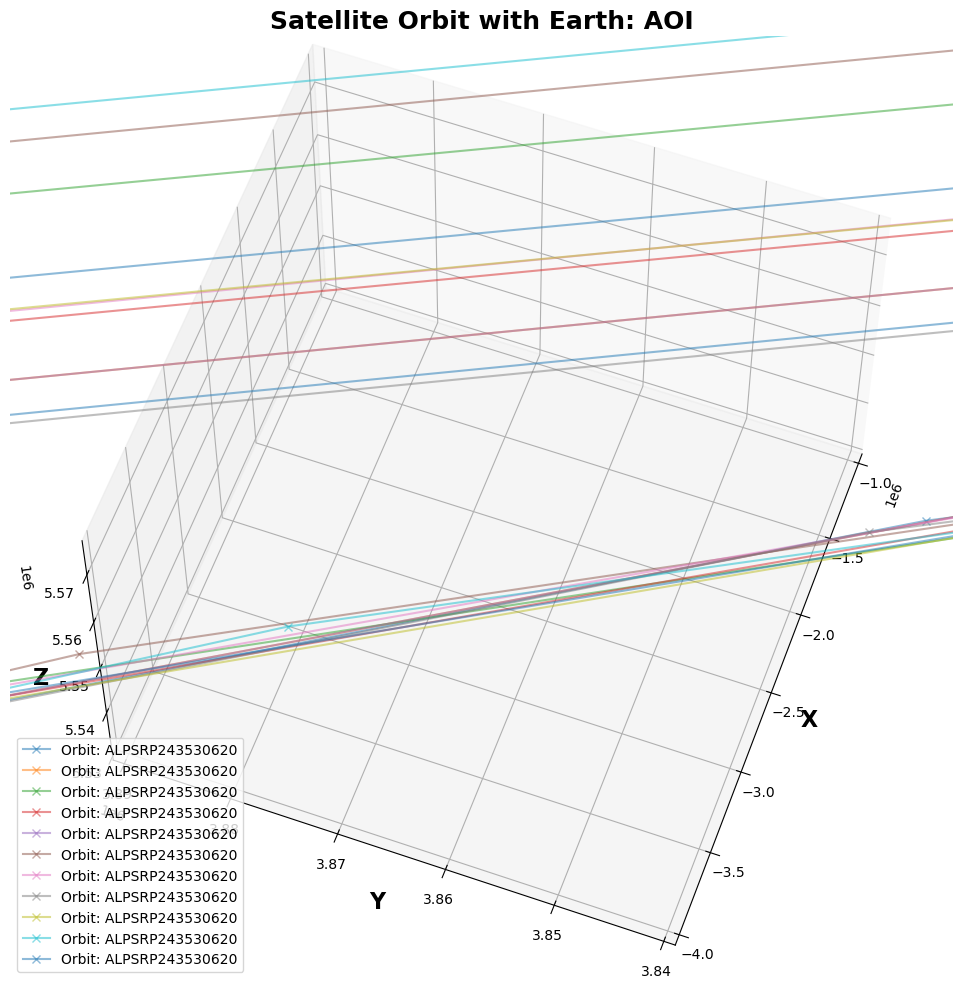

In [74]:
xmin, xmax = 1E6 * -4, 1E6 * -1
ymin, ymax = 1E6 * 3.84, 1E6 * 3.89
zmin, zmax = 1E6 * 5.53, 1E6 * 5.576

fig = plt.figure(figsize=(12 ,10), facecolor='white',edgecolor='black')
ax = fig.add_subplot(111, projection='3d')
ax.set_zlabel('Z', fontdict={'size': 16}, fontweight='bold')
ax.set_xlabel('X', fontdict={'size': 16}, fontweight='bold')
ax.set_ylabel('Y', fontdict={'size': 16}, fontweight='bold')
for _i, _POS in enumerate(IMGS):
    ax.plot(POS_S[_i][:,0], POS_S[_i][:,1], POS_S[_i][:,2], 
            marker="x" , label=f'Orbit: {NAMES[0]}', alpha=0.5,)
ax.set_xlim3d(xmin, xmax)
ax.set_ylim3d(ymin, ymax)
ax.set_zlim3d(zmin, zmax)
plt.title('Satellite Orbit with Earth: AOI', fontsize=18, fontweight='bold')
plt.legend()
ax.grid(True)
ax.view_init(elev=60, azim=200)
plt.tight_layout()
plt.savefig(f'{PATH_OUTPUT}pos_3d_with_earth-round_restrict.png')
plt.show();plt.clf();plt.close()